# Angiogram Video to Key-Frame Extraction and Angiogram Preprocessing Pipeline

 Overview

This notebook implements the **Angiogram Video → Key Frame → Angiogram Preprocessing** pipeline
designed for the *AI-Driven Coronary Disease Detection and Decision Support System*.

The goal is to:
- Convert angiogram DICOM/MP4 files into individual frames
- Automatically select diagnostically relevant key frames
- Apply standardized angiogram preprocessing
- Prepare outputs for the blockage detection and localization module


## Step 00 – Install & Import Dependencies

In [2]:
import cv2
import numpy as np
import pandas as pd
import json
from pathlib import Path
import pydicom

## Step 01: Upload Angiogram (DICOM or MP4)


In [18]:
angiogram_path = Path("C:/Users/User/Documents/IIT Stage 2/IIT Stage 2 Semester 1/CM2603  Data Science Group Project/Angiogram Videos/DICOM/Patient-0001")  

print("Selected file:", angiogram_path)
print("Extension:", angiogram_path.suffix)
print("File exists:", angiogram_path.exists()) 

Selected file: C:\Users\User\Documents\IIT Stage 2\IIT Stage 2 Semester 1\CM2603  Data Science Group Project\Angiogram Videos\DICOM\Patient-0001
Extension: 
File exists: True


The system accepts angiogram data in **DICOM or MP4 format**, which is the standard
medical imaging format used in hospitals. This file may contain multiple frames
representing a complete angiography sequence.

## Step 02: Validate DICOM Format

In [19]:
def validate_input(file_path: Path) -> bool:

    try:
        ds = pydicom.dcmread(file_path)
        if hasattr(ds, "PixelData"):
            print("Valid DICOM image detected.")
            return True
    except:
        pass

    try:
        cap = cv2.VideoCapture(str(file_path))
        if cap.isOpened():
            cap.release()
            print("Valid MP4 video detected.")
            return True
    except:
        pass

    print("Unsupported format.")
    return False

is_valid = validate_input(angiogram_path)
print("Validation result:", is_valid)

Valid DICOM image detected.
Validation result: True


Before processing, the system validates whether the uploaded file is a valid
DICOM or MP4 file. This prevents corrupted or unsupported files from entering the
pipeline.

## Step 03: Read DICOM/MP4 Metadata & Frames

In [20]:
def read_angiogram(file_path: Path):

    # Try DICOM first
    try:
        print("Trying DICOM read...")
        ds = pydicom.dcmread(file_path)

        if hasattr(ds, "PixelData"):
            print("DICOM detected.")

            frames = ds.pixel_array.astype(np.float32)

            if len(frames.shape) == 2:
                frames = np.expand_dims(frames, axis=0)

            metadata = {
                "Source": "DICOM",
                "Modality": ds.get("Modality", "Unknown"),
                "NumberOfFrames": frames.shape[0]
            }

            return metadata, frames

    except Exception as e:
        print("DICOM read failed:", e)

    # Try MP4
    try:
        print("Trying MP4 read...")
        cap = cv2.VideoCapture(str(file_path))

        if cap.isOpened():
            print("MP4 detected.")

            frame_list = []

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frame_list.append(gray.astype(np.float32))

            cap.release()

            frames = np.array(frame_list)

            metadata = {
                "Source": "MP4",
                "Modality": "XA (Simulated)",
                "NumberOfFrames": frames.shape[0]
            }

            return metadata, frames

    except Exception as e:
        print("MP4 read failed:", e)

    raise ValueError("Unsupported or unreadable file format.")

metadata, frames = read_angiogram(angiogram_path)


Trying DICOM read...
DICOM detected.


Once validated, the DICOM or MP4 file is read to extract:
- Image metadata (useful for traceability)
- Multi-frame pixel data representing the angiogram sequence

## Step 04: Extract Individual Frames

In [21]:
def extract_frames(frame_array: np.ndarray):
    """
    Splits multi-frame DICOM pixel array into individual frames.
    """
    return [frame_array[i] for i in range(frame_array.shape[0])]


frame_list = extract_frames(frames)

print(f"Total frames extracted: {len(frame_list)}")

Total frames extracted: 26


Angiogram video files contain multiple frames captured over time.
Each frame is extracted and processed individually for quality analysis.

## Step 05: Frame Quality Analysis and Diagnostic Scoring

In this step, **each extracted frame is evaluated using quantitative image-quality metrics**
to determine how diagnostically informative it is. These metrics are later combined
into a single **diagnostic score**, which is used for key-frame selection.

### Step 5.1: Metric Computation Function

In [22]:
import cv2
import numpy as np

def compute_frame_quality_metrics(frame: np.ndarray):
    """
    Computes quality metrics for a single angiogram frame.
    """
    # Ensure grayscale (angiograms are usually grayscale already)
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame.copy()

    # --- Mean Intensity ---
    mean_intensity = np.mean(gray)

    # --- Contrast (Standard Deviation) ---
    contrast = np.std(gray)

    # --- Edge Strength (Sobel Gradient Magnitude) ---
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge_strength = np.mean(np.sqrt(sobel_x**2 + sobel_y**2))

    # --- Noise Estimation (High-frequency variation) ---
    noise = np.std(gray - cv2.GaussianBlur(gray, (5, 5), 0))

    return {
        "mean_intensity": mean_intensity,
        "contrast": contrast,
        "edge_strength": edge_strength,
        "noise": noise
    }


### Step 5.2: Apply Metrics to All Frames

In [23]:
frame_metrics = []

for idx, frame in enumerate(frame_list):
    metrics = compute_frame_quality_metrics(frame)
    metrics["frame_index"] = idx
    frame_metrics.append(metrics)

frame_metrics[:3]  # Preview first few frames


[{'mean_intensity': np.float32(1831.8544),
  'contrast': np.float32(526.4533),
  'edge_strength': np.float64(189.6657660350232),
  'noise': np.float32(17.622725),
  'frame_index': 0},
 {'mean_intensity': np.float32(1661.257),
  'contrast': np.float32(483.90005),
  'edge_strength': np.float64(178.26404128539625),
  'noise': np.float32(16.768803),
  'frame_index': 1},
 {'mean_intensity': np.float32(1674.0817),
  'contrast': np.float32(487.98105),
  'edge_strength': np.float64(159.74637322031623),
  'noise': np.float32(14.411853),
  'frame_index': 2}]

### Step 5.3: Diagnostic Score Computation

In [24]:
from skimage.metrics import structural_similarity as ssim

def compute_diagnostic_score(frame, reference):
    data_range = frame.max() - frame.min() + 1e-6
    score, _ = ssim(reference, frame, full=True, data_range=data_range)
    return 1 - score

reference = frame_list[0]

for m, frame in zip(frame_metrics, frame_list):
    m["diagnostic_score"] = compute_diagnostic_score(frame, reference)

### Diagnostic Scoring Formulation

Each frame is assigned a **diagnostic score based on structural differences from a baseline angiogram frame** using the **Structural Similarity Index (SSIM)**.

SSIM is a perceptual image quality metric proposed by **Wang et al. (2004)** that evaluates similarity between two images by comparing their luminance, contrast, and structural information.

The SSIM between two images \(x\) and \(y\) is defined as:

$$
SSIM(x,y) =
\frac{(2\mu_x \mu_y + C_1)(2\sigma_{xy} + C_2)}
{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}
$$

Where:

- $( \mu_x , \mu_y ) $are the mean intensities of the two images  
- $( \sigma_x^2 , \sigma_y^2 )$ are the variances  
- $( \sigma_{xy} )$ is the covariance between the images  
- $( C_1 , C_2 )$ are small constants used to stabilize the division

Reference:

Wang, Z., Bovik, A., Sheikh, H., & Simoncelli, E. (2004).  
*Image Quality Assessment: From Error Visibility to Structural Similarity.*  
https://ece.uwaterloo.ca/~z70wang/publications/ssim.pdf

### Baseline Structural Change-Based Diagnostic Score

Instead of directly using SSIM, the **diagnostic score is defined as the structural change between the baseline frame and the current frame**:

$$
D_i = 1 - SSIM(F_0, F_i)
$$

Where:

- $(F_0)$ is the **baseline angiogram frame (initial frame before contrast dye propagation)**  
- $(F_i)$ is the **current frame in the angiogram sequence**  
- $(SSIM(F_0, F_i))$ measures the structural similarity between the baseline frame and the current frame  

This formulation measures **how much structural information has changed relative to the initial angiogram frame**.

### Interpretation

- If two frames are highly similar, \(SSIM\) approaches **1**, producing a **low diagnostic score**.
- If the frame differs significantly from the baseline image, \(SSIM\) decreases and the diagnostic score increases.

In coronary angiography sequences, these structural differences correspond to **contrast dye propagation through coronary arteries**, revealing vessel structures.

Therefore, frames with **higher structural change scores** correspond to frames where coronary vessels become more visible and are considered more diagnostically informative for downstream analysis such as vessel segmentation and blockage detection.

Unlike processing all frames equally, this approach ensures that:
- Redundant or low-quality frames are discarded
- Only diagnostically meaningful frames are selected
- Computational cost is reduced
- Downstream blockage detection models receive higher-quality inputs

This step significantly improves robustness and aligns the system with
real-world clinical angiogram interpretation.

## Step 06: Key Frame Selection

The selection process follows three principles:

1. **Ranking** – Frames are sorted by diagnostic score (highest first)
2. **Top-K Selection** – Only the best 3–5 frames are retained
3. **Temporal Spacing** – Frames too close in time are avoided to reduce redundancy

This ensures that the final set of frames is:
- Informative
- Diverse
- Computationally efficient

### Step 6.1: Convert Metrics to Structured Array

In [26]:
import pandas as pd

# Convert frame metrics to DataFrame for easier ranking
metrics_df = pd.DataFrame(frame_metrics)

# Sort frames by diagnostic score (descending)
metrics_df = metrics_df.sort_values(
    by="diagnostic_score", ascending=False
).reset_index(drop=True)

metrics_df.head()


,mean_intensity,contrast,edge_strength,noise,frame_index,diagnostic_score
0,1670.388062,466.370941,169.242880,14.123175,20,0.208920
1,1674.578735,468.468018,168.431374,14.183748,19,0.208391
2,1677.350098,469.298401,168.094320,14.254027,18,0.204422
3,1673.267578,465.476349,172.289950,14.392275,21,0.204337
4,1674.715820,468.649109,166.971669,14.625835,13,0.203136


### Step 6.2: Temporal Spacing Helper Function

In [27]:
def select_top_k_with_spacing(
    df,
    k=5,
    min_frame_gap=3
):
    """
    Selects top-K frames while enforcing minimum temporal spacing.

    Parameters:
    - df: DataFrame sorted by diagnostic score
    - k: number of frames to select
    - min_frame_gap: minimum frame index gap to avoid redundancy
    """
    selected_frames = []
    selected_indices = []

    for _, row in df.iterrows():
        frame_idx = row["frame_index"]

        # Check temporal spacing
        if all(abs(frame_idx - idx) >= min_frame_gap for idx in selected_indices):
            selected_frames.append(row)
            selected_indices.append(frame_idx)

        if len(selected_frames) == k:
            break

    return pd.DataFrame(selected_frames)


### Step 6.3: Select Key Diagnostic Frames

In [28]:
# Select top 3–5 key frames
K = 5
MIN_FRAME_GAP = 3

key_frames_df = select_top_k_with_spacing(
    metrics_df,
    k=K,
    min_frame_gap=MIN_FRAME_GAP
)

key_frames_df


,mean_intensity,contrast,edge_strength,noise,frame_index,diagnostic_score
0,1670.388062,466.370941,169.242880,14.123175,20.0,0.208920
4,1674.715820,468.649109,166.971669,14.625835,13.0,0.203136
7,1679.225098,468.878601,167.572134,14.335430,17.0,0.201911
8,1681.467529,459.140656,177.767549,14.603057,24.0,0.200556
15,1670.864624,470.842224,162.015533,14.346617,10.0,0.193966


## Step 07: Apply Angiogram Image Preprocessing to Selected Key Frames

This step **reuses the angiogram preprocessing pipeline already implemented**
in the project and applies it **only to the selected key frames**.

The preprocessing includes:
- Grayscale conversion
- Resizing to a fixed resolution (512 × 512)
- Intensity normalization
- Top-hat morphological filtering for vessel enhancement



### Step 7.1: Extract Selected Frames by Index

In [29]:
import cv2
from skimage.morphology import white_tophat, disk

# Extract selected frame indices as integers
selected_frame_indices = key_frames_df["frame_index"].astype(int).tolist()

# Retrieve corresponding frames
selected_frames = [frame_list[idx] for idx in selected_frame_indices]

print(f"Number of selected frames: {len(selected_frames)}")


Number of selected frames: 5


### Step 7.2: Define Enhanced Top-Hat Filter

In [30]:
def enhanced_tophat_filter(img, kernel_ratio=0.04, apply_clahe=True):

    img = img.astype(np.uint8)

    k = int(img.shape[1] * kernel_ratio)
    k = max(15, k | 1)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))

    white = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    black = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

    enhanced = cv2.add(img, white)
    enhanced = cv2.subtract(enhanced, black)

    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(enhanced)

    return enhanced

### Step 7.3: Define Angiogram Preprocessing Function

In [31]:
import cv2
import numpy as np

def preprocess_angiogram_frame(
    frame: np.ndarray,
    target_size=(512, 512),
    apply_augmentation=False
):
    """
    Preprocess a single angiogram frame using the
    SAME methodology as dataset preprocessing.

    Steps:
    1. Grayscale conversion
    2. Resize to 512x512
    3. Intensity normalization
    4. Enhanced Top-hat vessel enhancement
    5. Optional augmentation (training only)
    """

    # Grayscale
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame.copy()

    # Resize
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)

    # Normalize to 0–255 uint8
    normalized = cv2.normalize(
        resized,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Vessel Enhancement (Top-hat + CLAHE)
    enhanced = enhanced_tophat_filter(
        normalized,
        kernel_ratio=0.04,
        apply_clahe=True
    )


    return enhanced

Grayscale: Angiograms are intensity-based images

Resize: Enforces consistent input dimensions

Normalization: Scales intensities to $[0,1]$

Top-hat filtering: Enhances thin, bright vessel structures

### Step 7.4: Apply Preprocessing to All Selected Frames

In [32]:
preprocessed_frames = [
    preprocess_angiogram_frame(frame)
    for frame in selected_frames
]

print(f"Preprocessed frames generated: {len(preprocessed_frames)}")


Preprocessed frames generated: 5


### Step 7.4: Display the key frames

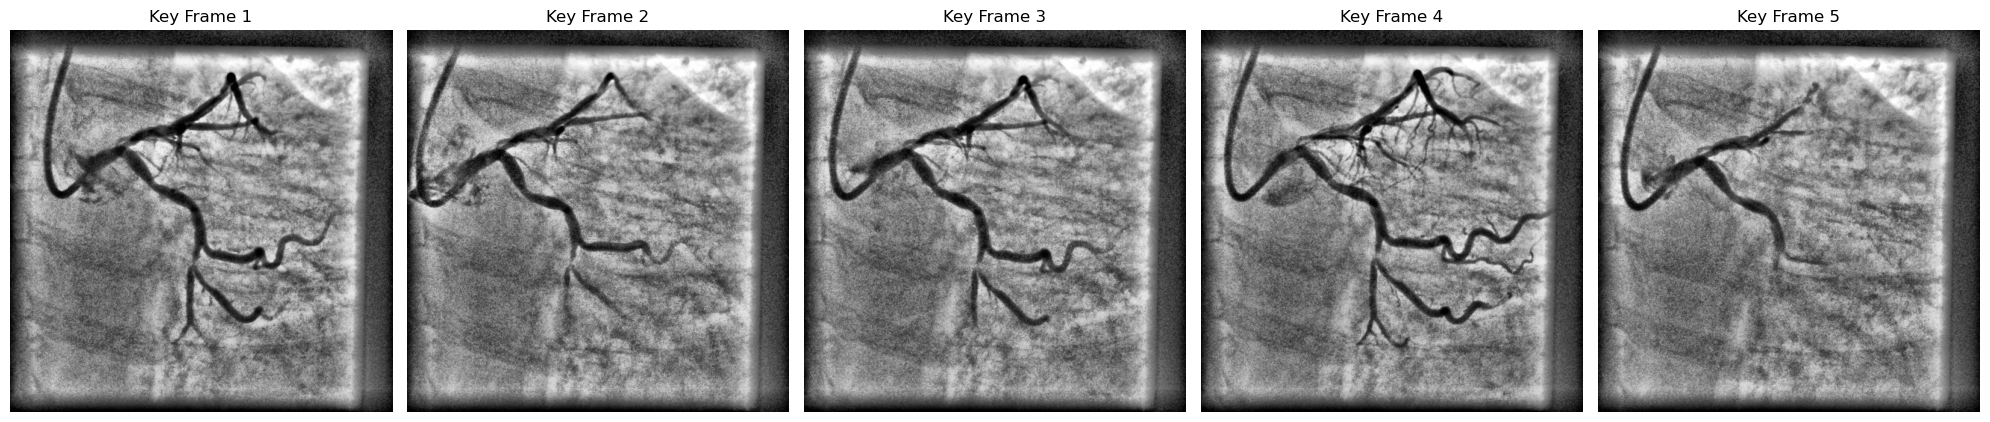

Selected frame indices: [20, 13, 17, 24, 10]


In [33]:
import matplotlib.pyplot as plt

# Number of frames
n = len(preprocessed_frames)

plt.figure(figsize=(4*n, 5))

for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(preprocessed_frames[i], cmap="gray", vmin=0, vmax=255)
    plt.title(f"Key Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Selected frame indices:", selected_frame_indices)

The output of this step is a set of **preprocessed angiogram images** that:
- Represent the most diagnostically relevant frames
- Have enhanced vessel visibility
- Are standardized in size and intensity

These images are ready to be:
- Stored for traceability
- Passed to the Blockage Detection and Localization module

## Step 08: Store Preprocessed Angiogram Data and Metadata

After preprocessing the selected key angiogram frames, the final step is to
store the processed images along with relevant metadata.

This ensures:
- Traceability of frame selection
- Reproducibility of preprocessing
- Clean handover to the Blockage Detection and Localization module

All outputs are stored in a structured directory format suitable for
clinical review and downstream AI analysis.

The preprocessed data is stored using the following structure:

$patient_id -->frame_01.png, frame_02.png, frame_03.png,frame_04.png, frame_05.png, metadata.json$

This structure allows easy access to both image data and
the contextual information used during frame selection.

### Step 8.1: Create Output Directory

In [58]:
import uuid
from datetime import datetime
from pathlib import Path

output_root = Path("Preprocessed_Angiogram_Output")

# Automatic patient ID using file name + timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
patient_id = f"{angiogram_path.stem}_{timestamp}"

patient_dir = output_root / patient_id
patient_dir.mkdir(parents=True, exist_ok=True)

print("Output directory created at:", patient_dir)

Output directory created at: Preprocessed_Angiogram_Output\Patient-0005_20260313_131213


### Step 8.2: Save Preprocessed Frames

In [59]:
for i, frame in enumerate(preprocessed_frames, start=1):
    output_path = patient_dir / f"frame_{i:02d}.png"

    # Frame is already uint8 (0–255)
    cv2.imwrite(str(output_path), frame)

print(f"Saved {len(preprocessed_frames)} preprocessed frames.")

Saved 5 preprocessed frames.


## Step 8.3: Save Metadata as JSON

In [61]:
import json

output_metadata = {
    "patient_id": patient_id,
    "source": metadata["Source"],
    "number_of_original_frames": metadata["NumberOfFrames"],
    "selected_frame_indices": selected_frame_indices
}

metadata_path = patient_dir / "metadata.json"

with open(metadata_path, "w") as f:
    json.dump(output_metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.
